# Computer Vision with PyTorch

In this project, I build an image classification model using **PyTorch** and the **FashionMNIST** dataset.

I start with simple fully connected neural networks and gradually move towards a **Convolutional Neural Network (CNN)** to compare how different architectures perform on image data.m

## 1. Imports

First, I import the libraries required for building, training, evaluating, and visualizing the computer vision models.

The main framework used here is **PyTorch**, while `torchvision` provides the FashionMNIST dataset and image transformations.

In [167]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

## 2. Loading the FashionMNIST Dataset

FashionMNIST is a dataset of grayscale images containing **10 different categories of clothing**.

Each image has a size of **28 × 28 pixels** and contains a single grayscale channel.

I use `ToTensor()` to convert the images into PyTorch tensors so they can be used by the neural networks.

In [168]:
train_data = datasets.FashionMNIST(
    root = "data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    # target_transform=True
)

test_data = datasets.FashionMNIST(
      root = "data",
      train=False,
      download=True,
      transform=torchvision.transforms.ToTensor(),
      # target_transform=True
)


In [169]:
len(train_data) , len(test_data)

(60000, 10000)

### Exploring the Classes

FashionMNIST contains **10 different clothing categories**.

I store the class names so that the numerical labels produced by the dataset can be converted into meaningful names.

In [170]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

### Class-to-Index Mapping

Each FashionMNIST class is represented internally by an integer from `0` to `9`.

This mapping shows which number corresponds to each clothing category.

In [171]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

### Inspecting a Single Sample

I now inspect one image and its corresponding label to understand how the dataset stores the input and target.

In [172]:
image , label = train_data[0]
image , label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

### Understanding the Image Shape

In [173]:
print(f"Image Shape : {image.shape}")
print(f"Image Label : {class_names[label]}")

Image Shape : torch.Size([1, 28, 28])
Image Label : Ankle boot


A FashionMNIST image has the shape:

`[1, 28, 28]`

where:

- `1` → grayscale channel
- `28` → image height
- `28` → image width

The label is an integer representing the image's class.

## 3. Visualizing the Dataset

Before building a model, it is useful to visually inspect the data.

Here I randomly sample images from the training set and display them along with their class names.

This helps verify that the images and labels are being loaded correctly.

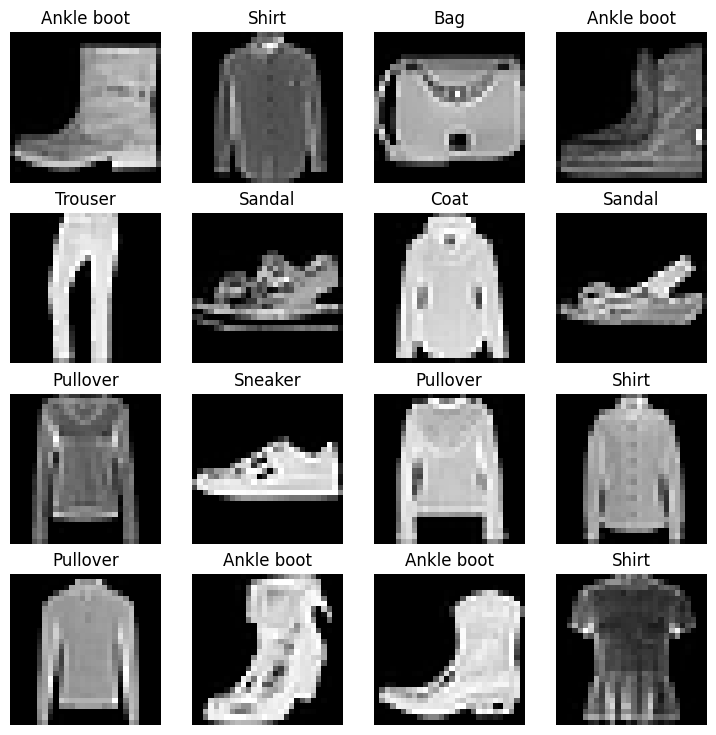

In [174]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 4,4

for i in range(1,rows*cols+1) :
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

## 4. Creating DataLoaders

Neural networks are usually trained using **mini-batches** instead of processing the entire dataset at once.

I use a batch size of `32`.

The training DataLoader is shuffled so that the model does not see the training samples in the same order every epoch, while the test DataLoader is not shuffled.

In [175]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             shuffle=False)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7fcd73a95e50>,
 <torch.utils.data.dataloader.DataLoader at 0x7fcd5ae4f350>)

### Checking the Number of Batches

I check how many batches are created by each DataLoader.

With a batch size of `32`, the training set is divided into approximately `1875` batches per epoch.

In [176]:
print(f"Length fo Train DataLoader : {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length fo Test DataLoader : {len(test_dataloader)} batches of {BATCH_SIZE}")

Length fo Train DataLoader : 1875 batches of 32
Length fo Test DataLoader : 313 batches of 32


In [177]:
train_features_batch , train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

### Visualizing an Image from a Batch

I randomly select one image from the batch and visualize it along with its label.

This is another quick check that the DataLoader is producing the expected input and target values.

Image Size : torch.Size([1, 28, 28])
Label : 8, Label Size : torch.Size([])



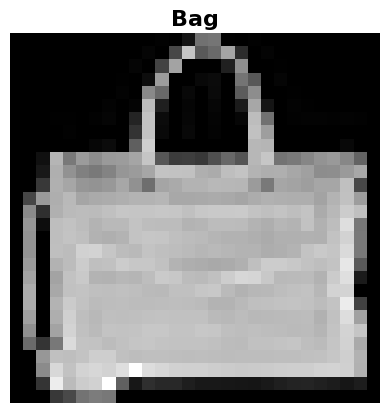

In [178]:
# torch.manual_seed(42)
random_idx = torch.randint(0,len(train_features_batch),size=[1]).item()
img, label = train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[label],fontsize=16,fontweight="bold")
plt.axis(False)
print(f"Image Size : {img.shape}")
print(f"Label : {label}, Label Size : {label.shape}\n")

# 5. Model 0 — Baseline Neural Network

In [179]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int) :
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )

  def forward(self,x):
    return self.layer_stack(x)



In [180]:
torch.manual_seed(42)

model_0=FashionMNISTModelV0(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
)

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)


I start with a simple **fully connected neural network** to establish a baseline.

The image is first flattened from `1 × 28 × 28` into `784` features.

The architecture is:

`Flatten → Linear(784 → 10) → Linear(10 → 10)`

This model does not use convolutional layers, so it does not explicitly take advantage of the spatial structure of the image.

### Loading Helper Functions

I use a small helper file containing reusable functions for the project.

If the file already exists locally, I skip the download to avoid downloading it again.

In [181]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print ("helper_functions. py already exists, skipping download")
else:
  print ("Download helper_functions-py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py" , "wb") as f:
    f.write(request.content)

helper_functions. py already exists, skipping download


## 6. Loss Function and Optimizer

For this multiclass classification problem, I use:

- **CrossEntropyLoss** → measures the difference between predicted class scores and the true labels
- **SGD** → updates the model parameters
- Learning rate → `0.1`

The optimizer uses the gradients calculated during backpropagation to improve the model.

In [182]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr=0.1)

### Measuring Training Time

Training time is useful when comparing different model architectures.

A model that performs better but requires significantly more computation may involve a practical trade-off.

In [183]:
from timeit import default_timer as timer
def print_train_time(start:float,
                     end : float ,
                     device : torch.device = None) :

                     total_time = end - start

                     print(f"Train Time On {device} : {total_time:.3f} seconds")
                     return total_time

In [184]:
start_time = timer()
end_time = timer()
print_train_time(start=start_time,end=end_time,device="cpu")

Train Time On cpu : 0.000 seconds


8.764800077187829e-05

## 7. Training Model 0

I now train the baseline fully connected model for **3 epochs**.

For every batch, the training process follows the standard PyTorch workflow:

1. Make predictions
2. Calculate the loss
3. Reset the gradients
4. Perform backpropagation
5. Update the model parameters

After each epoch, the model is evaluated on the test dataset.

In [185]:
from tqdm.auto import tqdm

torch.manual_seed(42)

train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):

  print(f"Epoch : {epoch}\n")

  train_loss = 0

  for batch,(X,y) in enumerate(train_dataloader) :

    model_0.train()

    y_pred = model_0(X)

    loss = loss_fn(y_pred,y)
    train_loss += loss

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if batch% 400 == 0:

      print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples.")

  train_loss /= len(train_dataloader)

  test_loss=0
  test_acc = 0

  model_0.eval()
  with torch.inference_mode():

    for X_test,y_test in test_dataloader :

      test_pred = model_0(X_test)

      test_loss += loss_fn(test_pred,y_test)

      test_acc += accuracy_fn(y_true=y_test,
                              y_pred = test_pred.argmax(dim=1))

    test_loss /= len(test_dataloader)

    test_acc /= len(test_dataloader)




  print(f"\nTrain Loss : {train_loss:.4f} | Test Loss : {test_loss:.4f} | Test Accuracy : {test_acc:.2f}%")


train_time_end_on_cpu = timer()

total_train_time_model_0 = print_train_time(
    start=train_time_start_on_cpu,
    end=train_time_end_on_cpu,
    device=str(next(model_0.parameters()).device)
)




  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0

Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train Loss : 0.5904 | Test Loss : 0.5095 | Test Accuracy : 82.04%
Epoch : 1

Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train Loss : 0.4763 | Test Loss : 0.4799 | Test Accuracy : 83.20%
Epoch : 2

Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train Loss : 0.4550 | Test Loss : 0.4766 | Test Accuracy : 83.43%
Train Time On cpu : 47.160 seconds


## 8. Creating a Reusable Evaluation Function

Instead of writing the evaluation code separately for every model, I create a reusable `eval_model()` function.

During evaluation:

- `model.eval()` switches the model to evaluation mode.
- `torch.inference_mode()` disables gradient tracking.
- Predictions are compared with the true labels.
- Average loss and accuracy are returned.

Using the same evaluation function makes the comparison between models more consistent.

In [186]:


# Set device

device = "cuda" if torch.cuda.is_available() else "cpu"

# Move all models to the same device

model_0 = model_0.to(device)

# model_1 = model_1.to(device)

# model_2 = model_2.to(device)

def eval_model(model: torch.nn.Module,

               data_loader: torch.utils.data.DataLoader,

               loss_fn: torch.nn.Module,

               accuracy_fn):

    loss, acc = 0, 0

    model.eval()

    with torch.inference_mode():

        for X, y in data_loader:


            X, y = X.to(device), y.to(device)


            y_pred = model(X)


            loss += loss_fn(y_pred, y)


            acc += accuracy_fn(

                y_true=y,

                y_pred=y_pred.argmax(dim=1)

            )



        loss /= len(data_loader)

        acc /= len(data_loader)

    return {

        "model name": model.__class__.__name__,

        "model_loss": loss.item(),

        "model_acc": acc

    }




model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

model_0_results

{'model name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

### Checking the Available Device

PyTorch can use a CUDA-enabled GPU when one is available.

Otherwise, the models will run on the CPU.

I store the selected device in the `device` variable so it can be reused throughout the project.

In [187]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"The device is : {device}")

The device is : cpu


# 9. Model 1 — Fully Connected Network + ReLU

The second model builds on the baseline by adding **ReLU activation functions**.

The architecture is:

`Flatten → Linear → ReLU → Linear → ReLU`

ReLU introduces non-linearity, allowing the network to learn more complex patterns than a purely linear network.

In [188]:
class FashionMNISTModelV1(nn.Module) :

  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape:int):

    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape),
        nn.ReLU()
    )

  def forward(self,x) :

    return self.layer_stack(x)



### Creating Model 1

I initialize Model 1 with:

- `784` input features
- `10` hidden units
- `10` output classes

The model is also moved to the selected device so that training can be performed on the available hardware.

In [189]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_units=10,
                              output_shape = len(class_names)).to(device)
next(model_1.parameters()).device

device(type='cpu')

In [190]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr=0.1)

## 10. Creating a Reusable Training Step

I create a `train_step()` function to handle one complete training epoch.

For every batch, the function:

1. Moves the data to the selected device
2. Generates predictions
3. Calculates the loss
4. Calculates accuracy
5. Clears old gradients
6. Performs backpropagation
7. Updates the model parameters

This makes the training process reusable for multiple models.

In [191]:
def train_step(model : torch.nn.Module,
               data_loader : torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               optimizer : torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device) :


  train_loss=0
  train_acc=0

  model.train()

  for batch, (X,y) in enumerate(data_loader) :

    X,y = X.to(device) , y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred,y)

    train_loss += loss

    train_acc += accuracy_fn(y_true=y,
                             y_pred=y_pred.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  print(f"Train Loss : {train_loss:.5f} | Train Acuracy : {train_acc:.2f}%")






### Creating a Reusable Test Step

The `test_step()` function evaluates a model without updating its parameters.

I use:

`model.eval()`

and

`torch.inference_mode()`

so that the model is evaluated without gradient calculations.

In [192]:
def test_step(model:torch.nn.Module,
              data_loader : torch.utils.data.DataLoader,
              loss_fn : torch.nn.Module,
              accuracy_fn,
              device : torch.device = device) :

  test_loss,test_acc = 0,0

  model.eval()

  with torch.inference_mode() :

    for X,y in data_loader:

      X,y = X.to(device) , y.to(device)

      test_pred = model(X)

      test_loss += loss_fn(test_pred,y)

      test_acc += accuracy_fn(y_true=y,
                              y_pred=test_pred.argmax(dim=1))



    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f"Test Loss : {test_loss:.5f} | Test Accuracy : {test_acc:.2f}%")



## 11. Training Model 1

I now train Model 1 for **30 epochs** using the reusable training and testing functions.

The longer training period allows us to see whether the additional non-linearity improves the model's performance.

In [193]:
torch.manual_seed(42)

train_time_start_on_gpu= timer()

epochs = 30


for epoch in tqdm(range(epochs)) :

  print(f"Epoch : {epoch}\n")

  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn = loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)

  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_on_gpu = timer()

total_train_time_model_1 = print_train_time(start = train_time_start_on_gpu,
                                            end = train_time_end_on_gpu,
                                            device = device)




  0%|          | 0/30 [00:00<?, ?it/s]

Epoch : 0

Train Loss : 1.09199 | Train Acuracy : 61.34%
Test Loss : 0.95636 | Test Accuracy : 65.00%
Epoch : 1

Train Loss : 0.78101 | Train Acuracy : 71.93%
Test Loss : 0.72227 | Test Accuracy : 73.91%
Epoch : 2

Train Loss : 0.67027 | Train Acuracy : 75.94%
Test Loss : 0.68500 | Test Accuracy : 75.02%
Epoch : 3

Train Loss : 0.64384 | Train Acuracy : 76.52%
Test Loss : 0.65079 | Test Accuracy : 76.13%
Epoch : 4

Train Loss : 0.62892 | Train Acuracy : 77.00%
Test Loss : 0.65277 | Test Accuracy : 75.95%
Epoch : 5

Train Loss : 0.61576 | Train Acuracy : 77.41%
Test Loss : 0.64104 | Test Accuracy : 76.50%
Epoch : 6

Train Loss : 0.60668 | Train Acuracy : 77.78%
Test Loss : 0.62651 | Test Accuracy : 76.61%
Epoch : 7

Train Loss : 0.45148 | Train Acuracy : 83.94%
Test Loss : 0.45020 | Test Accuracy : 84.39%
Epoch : 8

Train Loss : 0.39916 | Train Acuracy : 85.95%
Test Loss : 0.43955 | Test Accuracy : 84.86%
Epoch : 9

Train Loss : 0.39335 | Train Acuracy : 86.15%
Test Loss : 0.43407 | Tes

# 12. Model 2 — Convolutional Neural Network

For image classification, a **Convolutional Neural Network (CNN)** is a more natural architecture because images contain spatial patterns.

Instead of immediately flattening the image, the CNN uses convolutional layers to learn visual features while preserving spatial information.

The model contains two convolutional blocks followed by a classifier.

In [194]:
class FashionMNISTModelV2(nn.Module) :

  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):

    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def forward(self,x) :

    x=self.conv_block_1(x)
    x=self.conv_block_2(x)
    x=self.classifier(x)
    return x








### Creating Model 2


In [195]:
torch.manual_seed(42)

model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)


The CNN uses:

- `1` input channel because FashionMNIST images are grayscale
- `10` hidden units
- `10` output classes

The model is moved to the selected device before training.

## 13. Understanding CNN Input Shapes

Before training the CNN, I inspect the shape of the input image.

A convolutional layer expects image data in the form:

`[batch_size, channels, height, width]`

For FashionMNIST, the image dimensions are:

`[1, 28, 28]`

and a batch therefore has the shape:

`[32, 1, 28, 28]`

In [196]:
torch.manual_seed(42)
images = torch.randn(size=(32,3,64,64))
test_image = image[0]

print(f"Image Batch Shape : {image.shape}")
print(f"Single Image Shape : {test_image.shape}")
print(f"Test Image :\n {test_image} ")

Image Batch Shape : torch.Size([1, 28, 28])
Single Image Shape : torch.Size([28, 28])
Test Image :
 tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0

## 14. Setting Up Model 2 Training

I use the same Cross Entropy Loss and SGD optimizer for Model 2.

Keeping these settings consistent makes the model comparison more meaningful because the architecture remains the main difference.

In [198]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

## 15. Training the CNN

I now train the CNN for **10 epochs**.

Each epoch uses the reusable `train_step()` and `test_step()` functions.

The CNN should be able to learn useful spatial features such as edges, shapes, and patterns from the clothing images.

In [199]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)


from timeit import default_timer as timer

train_time_start_model_2 = timer()

epochs = 10

for epoch in tqdm(range(epochs)) :

  print(f"Epoch : {epoch}\n")

  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)

  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_model_2 = timer()

total_train_time_model_2 = print_train_time(start = train_time_start_model_2,
                                            end = train_time_end_model_2,
                                            device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch : 0

Train Loss : 0.59518 | Train Acuracy : 78.38%
Test Loss : 0.39500 | Test Accuracy : 85.99%
Epoch : 1

Train Loss : 0.36536 | Train Acuracy : 86.90%
Test Loss : 0.35244 | Test Accuracy : 86.91%
Epoch : 2

Train Loss : 0.32588 | Train Acuracy : 88.13%
Test Loss : 0.32719 | Test Accuracy : 88.07%
Epoch : 3

Train Loss : 0.30489 | Train Acuracy : 88.92%
Test Loss : 0.32312 | Test Accuracy : 88.25%
Epoch : 4

Train Loss : 0.28981 | Train Acuracy : 89.56%
Test Loss : 0.30836 | Test Accuracy : 88.91%
Epoch : 5

Train Loss : 0.27944 | Train Acuracy : 89.82%
Test Loss : 0.29993 | Test Accuracy : 89.37%
Epoch : 6

Train Loss : 0.27027 | Train Acuracy : 90.09%
Test Loss : 0.31035 | Test Accuracy : 88.80%
Epoch : 7

Train Loss : 0.26670 | Train Acuracy : 90.22%
Test Loss : 0.30217 | Test Accuracy : 88.95%
Epoch : 8

Train Loss : 0.25909 | Train Acuracy : 90.55%
Test Loss : 0.29148 | Test Accuracy : 89.60%
Epoch : 9

Train Loss : 0.25397 | Train Acuracy : 90.71%
Test Loss : 0.31421 | Tes

# 16. Comparing the Three Models

Now that all three models have been trained, I evaluate them using the same test dataset.

I collect the results into a Pandas DataFrame so that the models can be compared using:

- Test loss
- Test accuracy
- Training time

In [200]:
import pandas as pd

model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

model_2_results = eval_model(model=model_2,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)



compare_results = pd.DataFrame([
    model_0_results,
    model_1_results,
    model_2_results
])

compare_results

compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]


### Model Comparison

The results show how the different architectures perform on the same FashionMNIST classification task.

The CNN achieves the strongest test performance, while the simpler fully connected network trains much faster.

In [201]:
compare_results

,model name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,47.159824
1,FashionMNISTModelV1,0.433553,84.924121,365.491178
2,FashionMNISTModelV2,0.314206,89.307109,574.197251


# 17. Making Predictions

After training the models, I create a reusable `make_predictions()` function for inference.

For each image, the function:

1. Adds a batch dimension
2. Moves the image to the selected device
3. Generates model logits
4. Applies Softmax to obtain class probabilities
5. Stores the probabilities for later analysis

In [202]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):

    pred_probs = []
    model.to(device)
    model.eval()

    with torch.inference_mode():

        for sample in data:

            sample = torch.unsqueeze(sample, dim=0).to(device)

            pred_logit = model(sample)

            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)

## 18. Selecting Random Test Samples

I randomly select **9 images** from the test dataset.

These samples will be used to visually compare the CNN's predictions with the true labels.

In [203]:
import random
random.seed(42)

test_samples=[]
test_labels=[]

for sample,label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)

### Inspecting the Selected Samples

The selected images and their corresponding labels are stored in `test_samples` and `test_labels`.

These will be passed through the trained CNN in the next step.

In [204]:
test_samples,test_labels

([tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0

### Generating Predictions

I pass the selected test images through the trained CNN.

The model produces class probabilities, and `argmax()` is used to select the class with the highest probability as the final prediction.

In [205]:
pred_probs = make_predictions(model=model_2,
                              data=test_samples)

pred_classes=pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 6, 4, 7, 1])

## 19. Visualizing Predictions

I display the 9 test images together with:

- The predicted class
- The true class

Correct predictions are shown in **green**, while incorrect predictions are shown in **red**.

This provides a quick visual way to inspect how the model performs on individual examples.

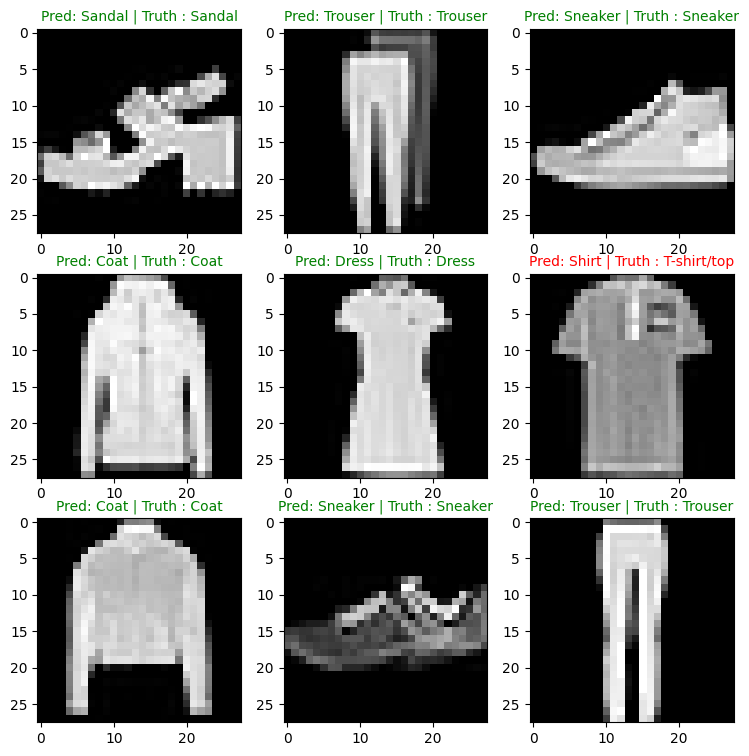

In [207]:
plt.figure(figsize=(9,9))

nrows=3
ncols=3

for i,sample in enumerate(test_samples) :

  plt.subplot(nrows,ncols,i+1)

  plt.imshow(sample.squeeze(),cmap="gray")

  pred_label = class_names[pred_classes[i]]

  truth_label = class_names[test_labels[i]]

  title_text = f"Pred: {pred_label} | Truth : {truth_label}"

  if pred_label == truth_label :

    plt.title(title_text,fontsize=10,c="g")

  else :

    plt.title(title_text,fontsize=10,c="r")

# 20. Generating Predictions for the Entire Test Set

To analyze the CNN more thoroughly, I generate predictions for every image in the test dataset.

The predicted class for each image is stored in `y_pred_tensor`.

These predictions will be used to create a confusion matrix.

In [208]:
from tqdm.auto import tqdm

y_preds = []

model_2.eval()

with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions..."):
        X, y = X.to(device), y.to(device)

        y_logit = model_2(X)

        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)

        y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)

print(y_pred_tensor)

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 8, 1, 5])


In [209]:
!pip install torchmetrics mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 8.1 MB/s eta 0:00:00


## 21. Confusion Matrix

To create a confusion matrix, I use **TorchMetrics** for calculating the matrix and **MLxtend** for visualization.

In [210]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

### Visualizing the Confusion Matrix

A confusion matrix shows how the model's predictions are distributed across all 10 classes.

The diagonal represents correct predictions.

The off-diagonal values represent misclassifications.

This is particularly useful for FashionMNIST because some clothing categories are visually similar, such as **Shirt, T-shirt/top, Pullover, and Coat**.

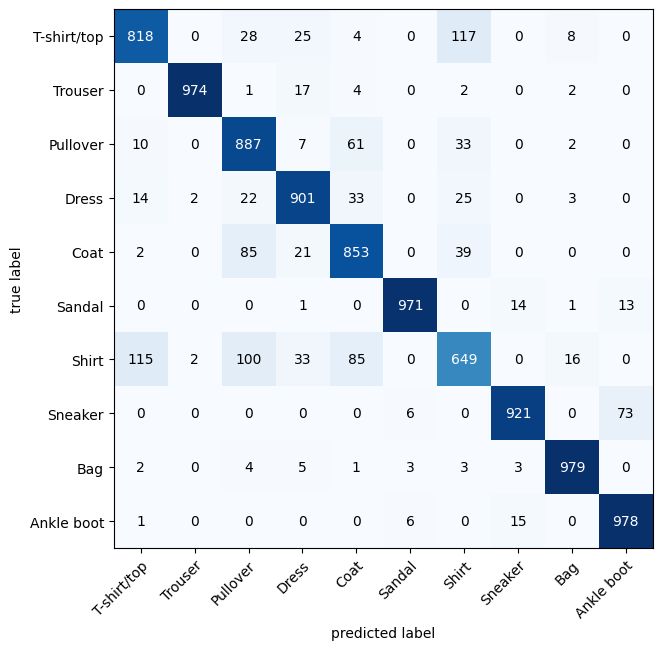

In [214]:
confmat = ConfusionMatrix(
    task="multiclass",
    num_classes=len(class_names)
)

confmat_tensor = confmat(
    preds=y_pred_tensor,
    target=test_data.targets
)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

# 22. Saving the Trained Model

The trained CNN is saved using PyTorch's `state_dict()`.

Instead of saving the entire model object, I save the learned parameters.

The model weights are stored at:

`models/pytorch_computer_vision_model_2.pth`

Saving the `state_dict` is a common PyTorch approach because the model architecture can be recreated separately and the saved parameters can then be loaded into it.

In [215]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")

torch.save(
    obj=model_2.state_dict(),
    f=MODEL_SAVE_PATH
)

Saving model to: models/pytorch_computer_vision_model_2.pth


# 23. Loading the Saved Model

To verify that the saved model can be reused, I recreate the same CNN architecture and load the saved `state_dict`.

The loaded model is then moved to the selected device.

In [216]:
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)
)

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### Evaluating the Loaded Model

I evaluate the loaded CNN using the same test DataLoader and evaluation function.

If the model was saved and loaded correctly, its performance should match the original trained model.

In [217]:
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

{'model name': 'FashionMNISTModelV2',
 'model_loss': 0.31420570611953735,
 'model_acc': 89.30710862619809}

In [218]:
model_2_results

{'model name': 'FashionMNISTModelV2',
 'model_loss': 0.31420570611953735,
 'model_acc': 89.30710862619809}

# 25. Key Takeaways

This project covered the complete workflow of an image classification problem using PyTorch:

- Loading and exploring FashionMNIST
- Working with tensors and image shapes
- Creating DataLoaders
- Building fully connected neural networks
- Using ReLU activation
- Building a Convolutional Neural Network
- Creating reusable training and evaluation functions
- Comparing different architectures
- Making predictions on unseen images
- Visualizing predictions
- Evaluating the model with a confusion matrix
- Saving and loading PyTorch model weights

### Final Result

The CNN performed the best among the three models.

The main takeaway from the comparison is that **CNNs are better suited to image data because they can learn spatial patterns and features from the image structure**.

This project was an important step in moving from basic neural networks towards practical deep learning and computer vision.